In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# 1. LOAD DATA
# ============================================
print("="*60)
print("LOADING DATA")
print("="*60)

df = pd.read_csv('men_2026_matchups_training.csv')

# Filter for First Round
rounds_of_interest = ['First Round']
df_filtered = df[df['round'].isin(rounds_of_interest)].copy()

print(f"Original Dataset Shape: {df.shape}")
print(f"Filtered Dataset Shape: {df_filtered.shape}")
print(f"\nRound Distribution:")
print(df_filtered['round'].value_counts())
print(f"\nTarget Variable Distribution:")
print(df_filtered['win'].value_counts())
print(f"Win Rate: {df_filtered['win'].mean():.2%}")

# ============================================
# 2. PREPARE FEATURES (EXCLUDING SEEDS)
# ============================================
print("\n" + "="*60)
print("PREPARING FEATURES")
print("="*60)

exclude_cols = ['Unnamed: 0', 'game_id', 'year', 'region', 'round',
                'high_bracket_team', 'low_bracket_team', 'win',
                'high_bracket_seed', 'low_bracket_seed']
feature_cols = [col for col in df_filtered.columns if col not in exclude_cols]

X = df_filtered[feature_cols].copy()
y = df_filtered['win'].copy()

# Clean data
X = X.select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(), inplace=True)

print(f"Feature Matrix Shape: {X.shape}")
print(f"Number of Features: {X.shape[1]}")

# ============================================
# 3. TRAIN/TEST SPLIT
# ============================================
print("\n" + "="*60)
print("TRAIN/TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training win rate: {y_train.mean():.2%}")
print(f"Test win rate: {y_test.mean():.2%}")

LOADING DATA
Original Dataset Shape: (1236, 117)
Filtered Dataset Shape: (620, 117)

Round Distribution:
round
First Round    620
Name: count, dtype: int64

Target Variable Distribution:
win
1    310
0    310
Name: count, dtype: int64
Win Rate: 50.00%

PREPARING FEATURES
Feature Matrix Shape: (620, 108)
Number of Features: 108

TRAIN/TEST SPLIT
Training set size: 496
Test set size: 124
Training win rate: 50.00%
Test win rate: 50.00%



EXPLORATORY DATA ANALYSIS

--- Top 20 Features Correlated with Winning ---
                       Feature  Correlation
                      5man_bpm     0.549722
                    torvik_rtg     0.547739
                    kenpom_rtg     0.544626
                      3man_bpm     0.532314
                           wab     0.524446
                     5man_obpm     0.506723
                     5man_dbpm     0.503800
                    5man_dprpg    -0.479024
                     5man_prpg     0.472831
                     3man_obpm     0.459591
          lineup_depth_quality    -0.453169
                     3man_prpg     0.453051
                     3man_dbpm     0.453012
                    3man_dprpg    -0.444214
experience_weighted_production     0.444101
         def_experience_impact     0.441162
      def_lineup_depth_quality    -0.441070
                          size     0.319708
        four_factors_composite     0.274887
                def_dunk_share     0.269460


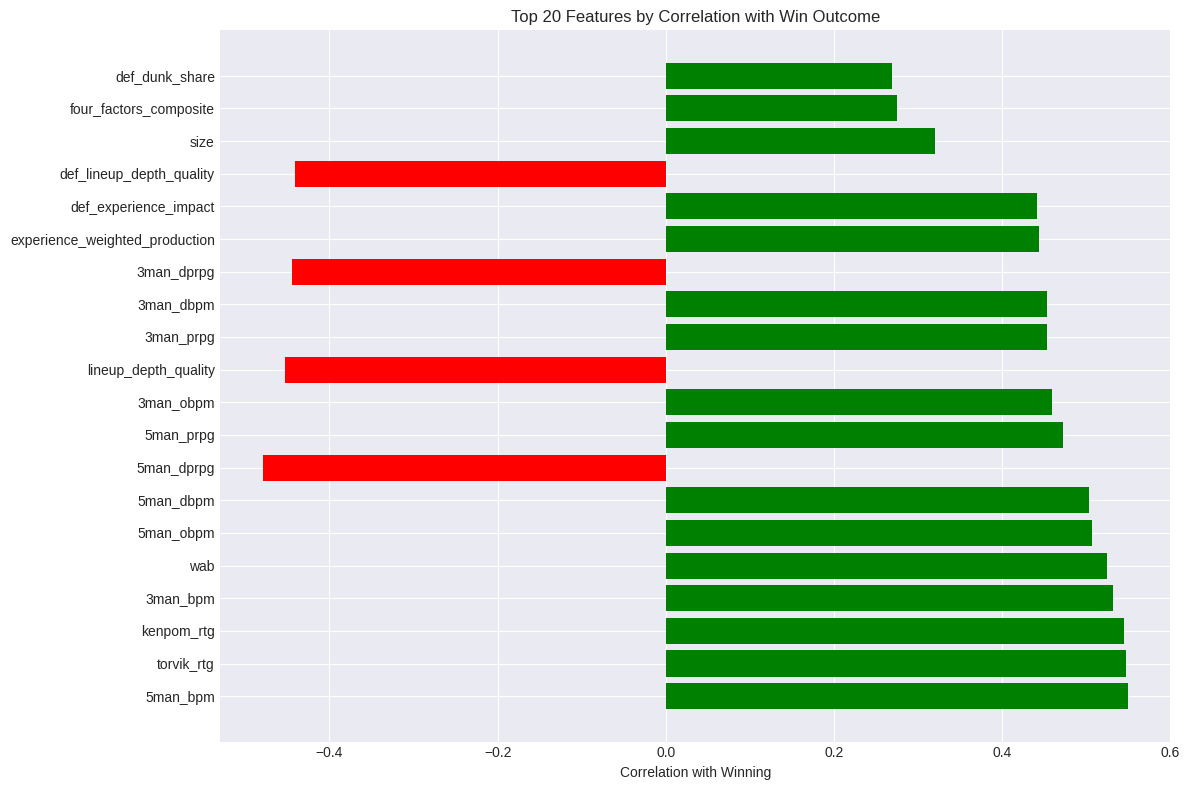

In [2]:
# ============================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Feature correlations with target (using training data only)
print("\n--- Top 20 Features Correlated with Winning ---")
correlations = pd.DataFrame({
    'Feature': X_train.columns,
    'Correlation': [X_train[col].corr(y_train) for col in X_train.columns]
})
correlations['Abs_Correlation'] = correlations['Correlation'].abs()
top_correlations = correlations.nlargest(20, 'Abs_Correlation')
print(top_correlations[['Feature', 'Correlation']].to_string(index=False))

# Plot 1: Top correlations
plt.figure(figsize=(12, 8))
top_20 = correlations.nlargest(20, 'Abs_Correlation')
colors = ['green' if x > 0 else 'red' for x in top_20['Correlation']]
plt.barh(range(len(top_20)), top_20['Correlation'], color=colors)
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Correlation with Winning')
plt.title('Top 20 Features by Correlation with Win Outcome')
plt.tight_layout()
plt.show()


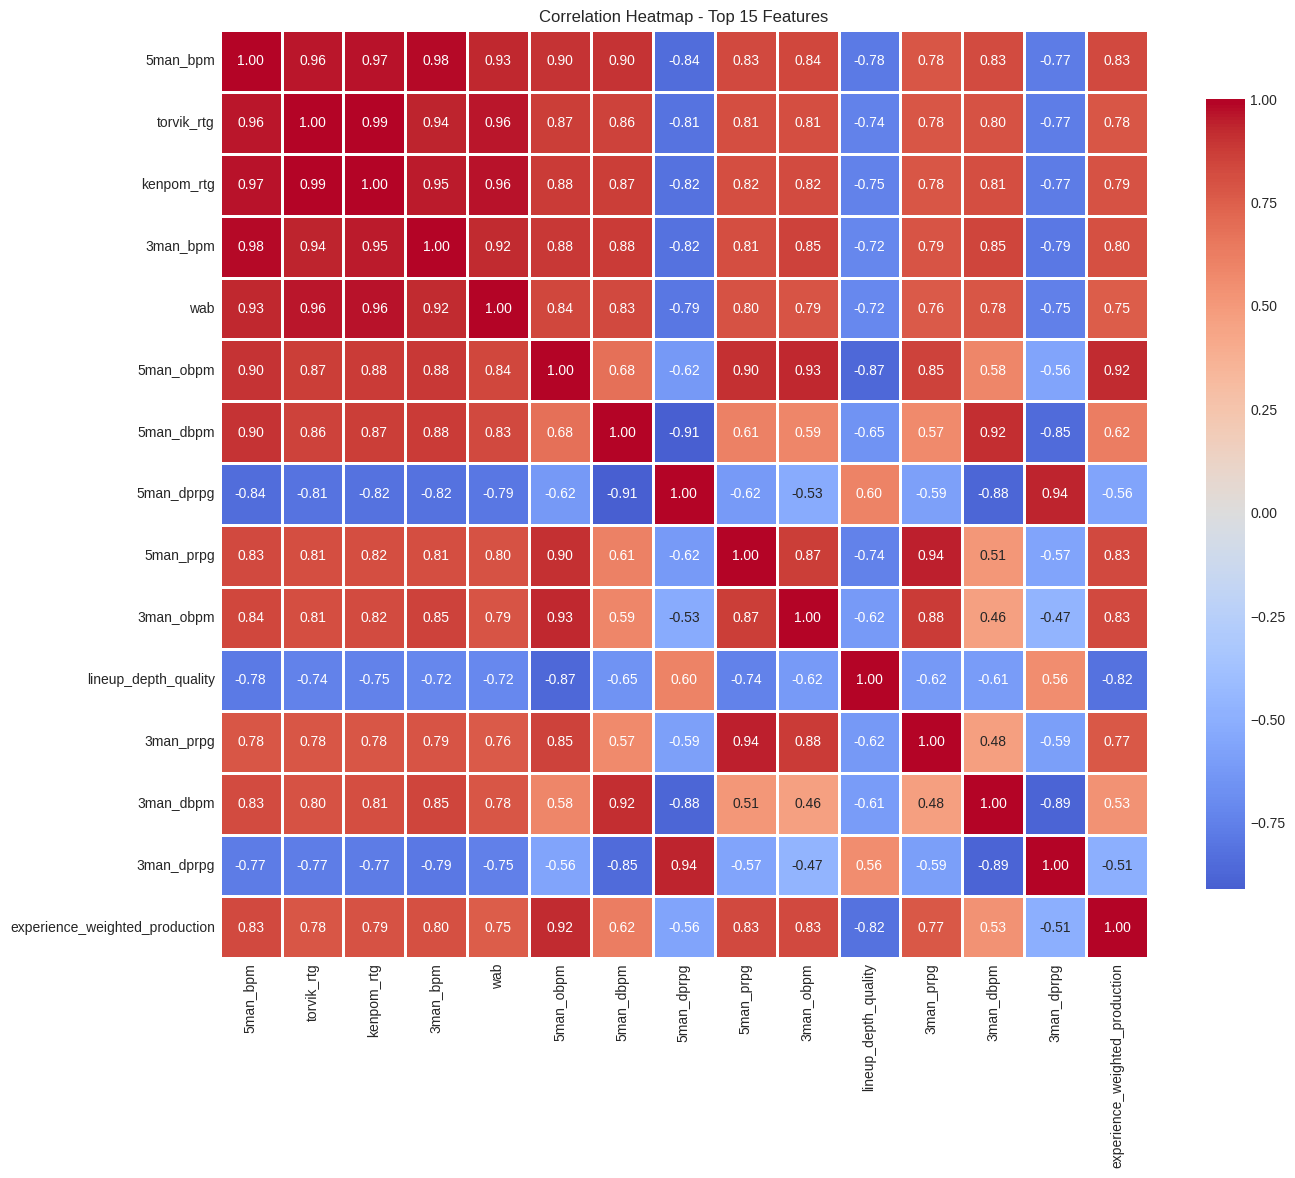

In [3]:
# Plot 2: Feature correlation heatmap (top features)
plt.figure(figsize=(14, 12))
top_features = top_20['Feature'].head(15).tolist()
corr_matrix = X_train[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Top 15 Features')
plt.tight_layout()
plt.show()

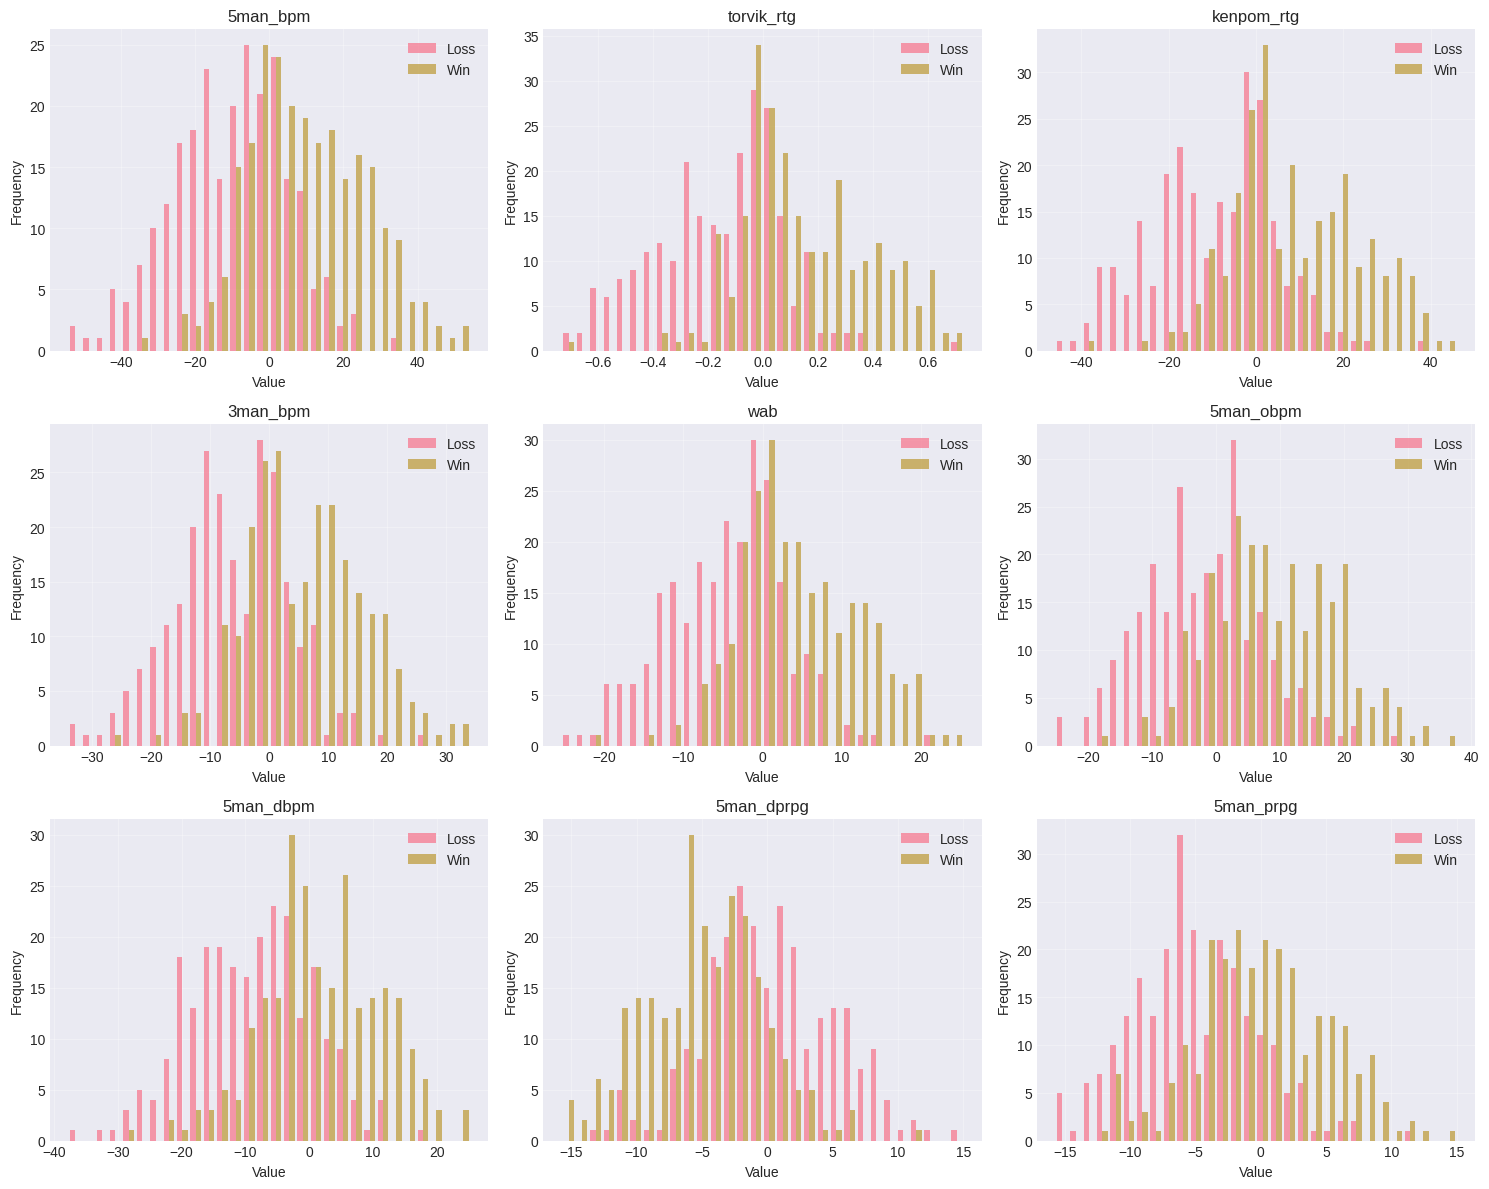

In [4]:
# Plot 3: Feature distributions for top features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feat in enumerate(top_features[:9]):
    axes[idx].hist([X_train[feat][y_train==0], X_train[feat][y_train==1]],
                  bins=30, alpha=0.7, label=['Loss', 'Win'])
    axes[idx].set_title(f'{feat}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Statistical summary
print("\n--- Statistical Summary of Top 10 Features ---")
print(X_train[top_features[:10]].describe().T[['mean', 'std', 'min', 'max']])


--- Statistical Summary of Top 10 Features ---
                mean        std        min        max
5man_bpm   -0.094153  18.675273 -54.100000  54.100000
torvik_rtg -0.001487   0.281136  -0.729094   0.729094
kenpom_rtg -0.144652  17.116781 -45.944660  45.944660
3man_bpm   -0.051008  11.666975 -34.000000  34.000000
wab         0.051656   8.727283 -25.303699  25.303699
5man_obpm   3.468952  10.965371 -25.200000  37.700000
5man_dbpm  -3.525403  10.805470 -37.700000  25.200000
5man_dprpg -2.333266   5.423492 -15.700000  15.000000
5man_prpg  -2.437903   5.500925 -15.700000  15.000000
3man_obpm   5.343145   6.893337 -16.200000  27.400000


In [6]:
# ============================================
# 5. FEATURE SELECTION METHODS (ON TRAINING DATA) - TOP 40
# ============================================
print("\n" + "="*60)
print("FEATURE SELECTION METHODS - TOP 40")
print("="*60)

# 5.1 Univariate Feature Selection (ANOVA F-test)
print("\n--- Univariate Feature Selection (ANOVA F-test) ---")
k = 40
selector_uni = SelectKBest(score_func=f_classif, k=k)
selector_uni.fit(X_train, y_train)

univariate_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': selector_uni.scores_,
    'P_value': selector_uni.pvalues_
}).sort_values('Score', ascending=False)

univariate_features = univariate_scores.head(k)['Feature'].tolist()
print(f"\nTop {k} features selected:")
print(univariate_scores.head(k)[['Feature', 'Score']].to_string(index=False))


FEATURE SELECTION METHODS - TOP 40

--- Univariate Feature Selection (ANOVA F-test) ---

Top 40 features selected:
                       Feature      Score
                      5man_bpm 213.933003
                    torvik_rtg 211.732012
                    kenpom_rtg 208.320362
                      3man_bpm 195.326551
                           wab 187.420283
                     5man_obpm 170.665183
                     5man_dbpm 168.033811
                    5man_dprpg 147.112207
                     5man_prpg 142.245040
                     3man_obpm 132.286609
          lineup_depth_quality 127.666977
                     3man_prpg 127.583152
                     3man_dbpm 127.555835
                    3man_dprpg 121.442673
experience_weighted_production 121.365831
         def_experience_impact 119.377977
      def_lineup_depth_quality 119.316424
                          size  56.242024
        four_factors_composite  40.379185
                def_dunk_share  38.676903
  

In [7]:
# 5.2 Mutual Information Feature Selection
print("\n--- Mutual Information Feature Selection ---")
selector_mi = SelectKBest(score_func=mutual_info_classif, k=k)
selector_mi.fit(X_train, y_train)

mi_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_Score': selector_mi.scores_
}).sort_values('MI_Score', ascending=False)

mi_features = mi_scores.head(k)['Feature'].tolist()
print(f"\nTop {k} features selected:")
print(mi_scores.head(k).to_string(index=False))


--- Mutual Information Feature Selection ---

Top 40 features selected:
                       Feature  MI_Score
                           wab  0.208410
                      5man_bpm  0.194890
                    torvik_rtg  0.188526
                      3man_bpm  0.188147
                    kenpom_rtg  0.166267
                    3man_dprpg  0.160578
                     5man_obpm  0.155522
                     5man_dbpm  0.154970
                     3man_dbpm  0.138962
                     5man_prpg  0.138199
                     3man_prpg  0.134149
                     3man_obpm  0.115064
          lineup_depth_quality  0.112987
                    5man_dprpg  0.106745
         def_experience_impact  0.106421
      def_lineup_depth_quality  0.096051
experience_weighted_production  0.095942
             def_close2_fg_pct  0.068768
         assist_to_usage_ratio  0.067965
          perimeter_efficiency  0.064764
        four_factors_composite  0.061077
 def_effective_possession


--- Random Forest Feature Importance ---

Top 40 features by importance:
                       Feature  Importance
                      3man_bpm    0.048600
                      5man_bpm    0.042362
                    torvik_rtg    0.041648
                           wab    0.031339
                     5man_dbpm    0.029107
                     3man_dbpm    0.028433
                    kenpom_rtg    0.028036
                     5man_obpm    0.027937
                     3man_obpm    0.025282
experience_weighted_production    0.019545
                    5man_dprpg    0.017648
                     3man_prpg    0.016158
                    3man_dprpg    0.015507
                     5man_prpg    0.015318
      def_lineup_depth_quality    0.013149
          lineup_depth_quality    0.011385
         def_experience_impact    0.011031
             off_close2_fg_pct    0.010682
           bench_scoring_ratio    0.009771
              rotation_balance    0.009408
                def_3pt

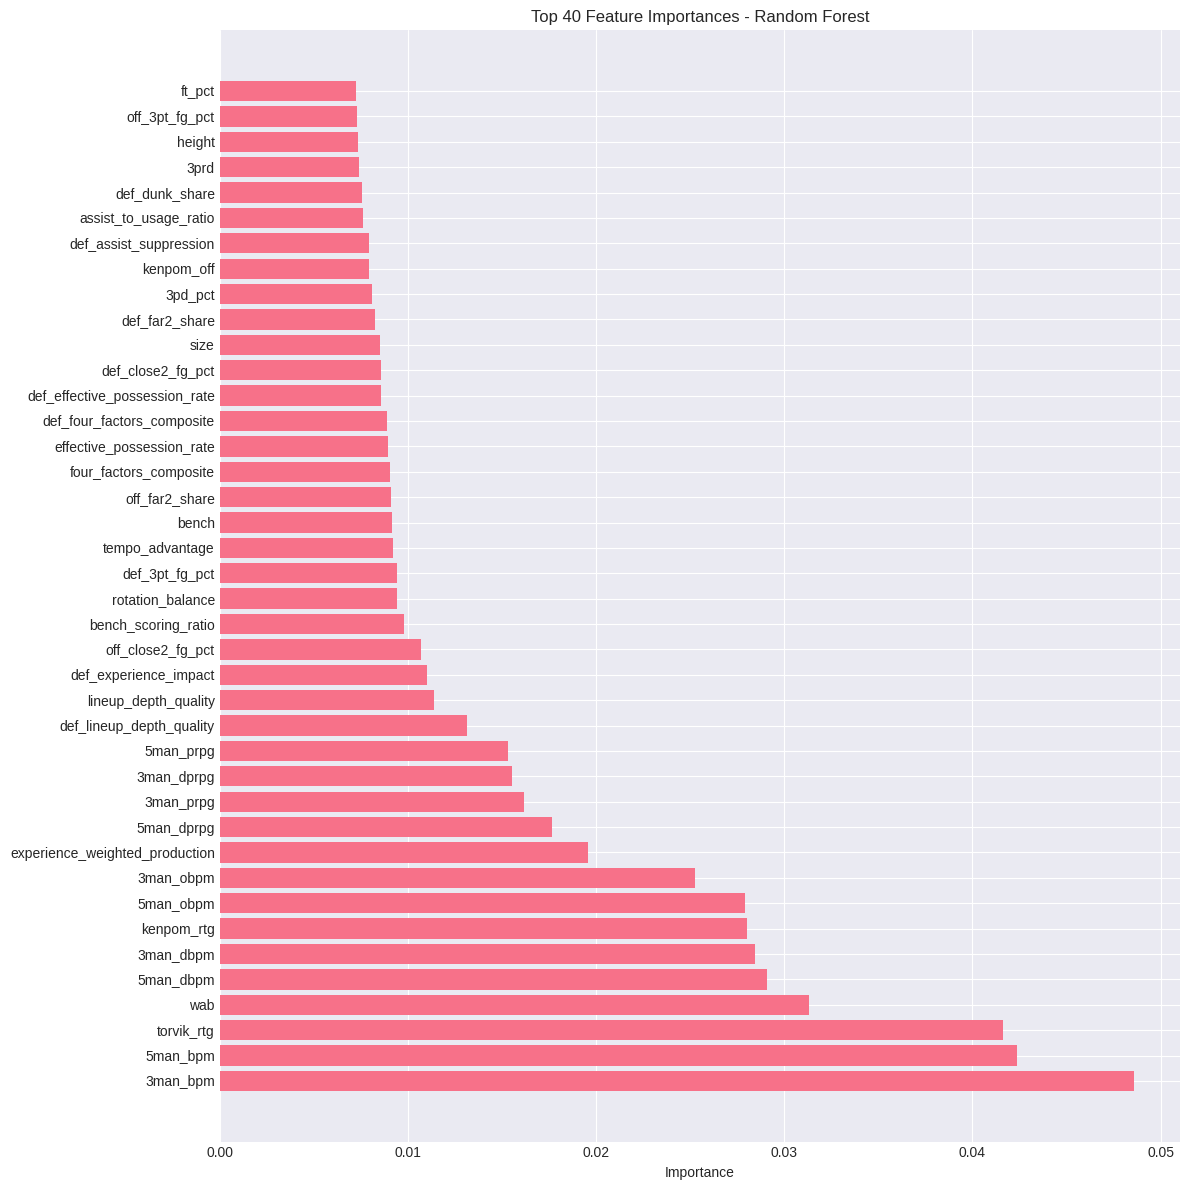

In [8]:
# 5.3 Random Forest Feature Importance
print("\n--- Random Forest Feature Importance ---")
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

rf_top_features = rf_importance.head(40)['Feature'].tolist()
print(f"\nTop 40 features by importance:")
print(rf_importance.head(40).to_string(index=False))

# Plot RF feature importance
plt.figure(figsize=(12, 12))
top_40_rf = rf_importance.head(40)
plt.barh(range(len(top_40_rf)), top_40_rf['Importance'])
plt.yticks(range(len(top_40_rf)), top_40_rf['Feature'])
plt.xlabel('Importance')
plt.title('Top 40 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()


--- Logistic Regression Feature Importance ---

Top 40 features by importance:
                  Feature  Importance
               torvik_rtg    0.667833
                 5man_bpm    0.282170
                5man_dbpm    0.234172
     lineup_depth_quality    0.193835
elite_outcome_probability    0.192166
                3man_prpg    0.146811
           def_3pt_fg_pct    0.138643
         paint_touch_rate    0.119969
           off_3pt_fg_pct    0.091376
 def_lineup_depth_quality    0.078682
                5man_obpm    0.067558
               5man_dprpg    0.046342
               experience    0.037333
                    bench    0.034860
                adj_tempo    0.016145
      bench_scoring_ratio    0.006072
          tempo_advantage    0.001562
     def_paint_touch_rate    0.001066
                     3prd    0.000000
                raw_tempo    0.000000
                   height    0.000000
                     size    0.000000
               3man_dprpg    0.000000
        

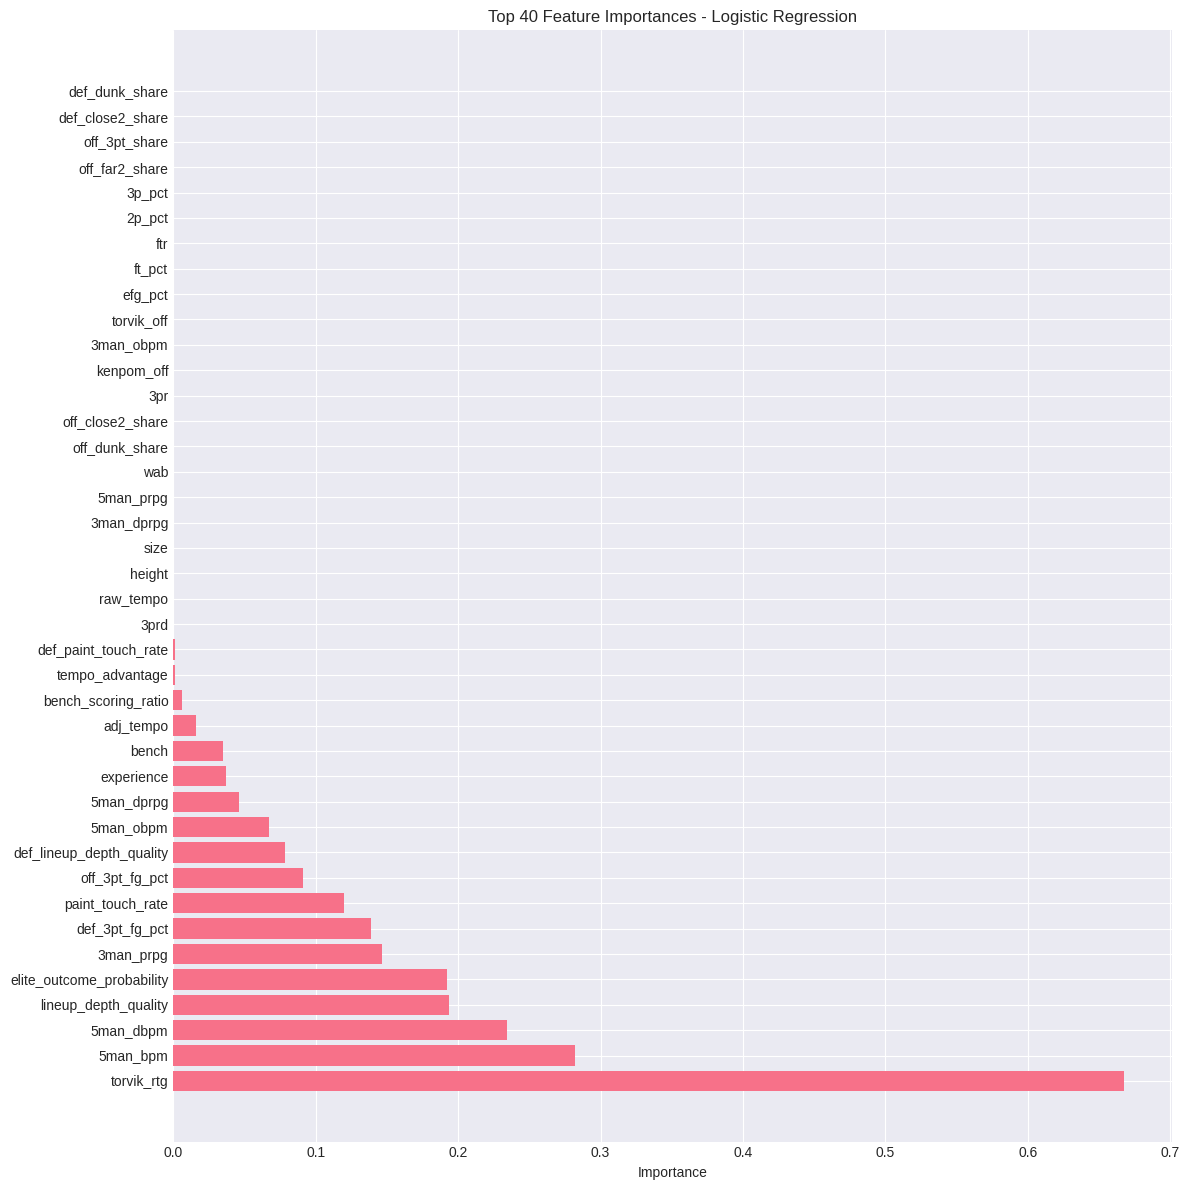

In [9]:
# 5.4 Logistic Regression Feature Importance
print("\n--- Logistic Regression Feature Importance ---")
scaler_temp = StandardScaler()
X_train_scaled_temp = scaler_temp.fit_transform(X_train)

lr_selector = LogisticRegression(max_iter=1000, random_state=42, penalty='l1',
                                 solver='liblinear', C=0.1)
lr_selector.fit(X_train_scaled_temp, y_train)

lr_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(lr_selector.coef_[0])
}).sort_values('Importance', ascending=False)

lr_top_features = lr_importance.head(40)['Feature'].tolist()
print(f"\nTop 40 features by importance:")
print(lr_importance.head(40).to_string(index=False))

# Plot LR feature importance
plt.figure(figsize=(12, 12))
top_40_lr = lr_importance.head(40)
plt.barh(range(len(top_40_lr)), top_40_lr['Importance'])
plt.yticks(range(len(top_40_lr)), top_40_lr['Feature'])
plt.xlabel('Importance')
plt.title('Top 40 Feature Importances - Logistic Regression')
plt.tight_layout()
plt.show()

In [10]:
# 5.5 Recursive Feature Elimination (RFE)
print("\n--- Recursive Feature Elimination (RFE) ---")
rfe_estimator = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
selector_rfe = RFE(estimator=rfe_estimator, n_features_to_select=40, step=5)
selector_rfe.fit(X_train, y_train)

rfe_rankings = pd.DataFrame({
    'Feature': X_train.columns,
    'Ranking': selector_rfe.ranking_,
    'Selected': selector_rfe.support_
}).sort_values('Ranking')

rfe_features = rfe_rankings[rfe_rankings['Selected']]['Feature'].tolist()
print(f"\nTop 40 features selected:")
print(rfe_rankings.head(40)[['Feature', 'Ranking']].to_string(index=False))

# Top correlation features
correlation_features = correlations.nlargest(40, 'Abs_Correlation')['Feature'].tolist()


--- Recursive Feature Elimination (RFE) ---

Top 40 features selected:
                       Feature  Ranking
                      5man_bpm        1
                      3man_bpm        1
                           wab        1
                    kenpom_rtg        1
                    torvik_rtg        1
                     5man_prpg        1
                     3man_prpg        1
                    5man_dprpg        1
                    3man_dprpg        1
                        height        1
                    experience        1
                         bench        1
                     raw_tempo        1
                     3man_obpm        1
                def_dunk_share        1
              off_close2_share        1
                    torvik_off        1
                        3p_pct        1
                     5man_obpm        1
                    kenpom_def        1
                     3man_dbpm        1
                      astd_pct        1
        

In [11]:
# ============================================
# 6. MODEL COMPARISON WITH DIFFERENT FEATURE SETS
# ============================================
print("\n" + "="*60)
print("MODEL COMPARISON WITH DIFFERENT FEATURE SETS")
print("="*60)

# Define feature sets
feature_sets = {
    'Top_40_Correlation': correlation_features,
    'Univariate_F_Test': univariate_features,
    'Mutual_Information': mi_features,
    'RF_Importance': rf_top_features,
    'LR_Importance': lr_top_features,
    'RFE_Selected': rfe_features,
    'All_Features': X_train.columns.tolist()
}

results_summary = []

for set_name, features in feature_sets.items():
    print(f"\n{'#'*60}")
    print(f"FEATURE SET: {set_name} ({len(features)} features)")
    print(f"{'#'*60}")

    # Prepare data subsets
    X_train_subset = X_train[features]
    X_test_subset = X_test[features]

    # Scale for Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_subset)
    X_test_scaled = scaler.transform(X_test_subset)

    # === Random Forest ===
    print(f"\n--- Random Forest - {set_name} ---")
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train_subset, y_train)

    # RF Predictions
    rf_y_pred = rf_model.predict(X_test_subset)
    rf_y_pred_proba = rf_model.predict_proba(X_test_subset)[:, 1]

    # RF Metrics
    rf_accuracy = accuracy_score(y_test, rf_y_pred)
    rf_cv_scores = cross_val_score(rf_model, X_train_subset, y_train, cv=5, scoring='accuracy')
    rf_cv_mean = rf_cv_scores.mean()
    rf_cv_std = rf_cv_scores.std()

    try:
        rf_auc = roc_auc_score(y_test, rf_y_pred_proba)
    except:
        rf_auc = None

    print(f"Test Accuracy: {rf_accuracy:.4f}")
    print(f"Cross-Validation Accuracy: {rf_cv_mean:.4f} (+/- {rf_cv_std:.4f})")
    if rf_auc:
        print(f"ROC AUC Score: {rf_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, rf_y_pred, target_names=['Loss', 'Win']))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, rf_y_pred))

    # === Logistic Regression ===
    print(f"\n--- Logistic Regression - {set_name} ---")
    lr_model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=1.0,
        penalty='l2'
    )
    lr_model.fit(X_train_scaled, y_train)

    # LR Predictions
    lr_y_pred = lr_model.predict(X_test_scaled)
    lr_y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

    # LR Metrics
    lr_accuracy = accuracy_score(y_test, lr_y_pred)
    lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    lr_cv_mean = lr_cv_scores.mean()
    lr_cv_std = lr_cv_scores.std()

    try:
        lr_auc = roc_auc_score(y_test, lr_y_pred_proba)
    except:
        lr_auc = None

    print(f"Test Accuracy: {lr_accuracy:.4f}")
    print(f"Cross-Validation Accuracy: {lr_cv_mean:.4f} (+/- {lr_cv_std:.4f})")
    if lr_auc:
        print(f"ROC AUC Score: {lr_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, lr_y_pred, target_names=['Loss', 'Win']))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, lr_y_pred))

    # Store results
    results_summary.append({
        'Feature_Set': set_name,
        'Num_Features': len(features),
        'RF_Test_Accuracy': rf_accuracy,
        'RF_CV_Mean': rf_cv_mean,
        'RF_CV_Std': rf_cv_std,
        'LR_Test_Accuracy': lr_accuracy,
        'LR_CV_Mean': lr_cv_mean,
        'LR_CV_Std': lr_cv_std
    })


MODEL COMPARISON WITH DIFFERENT FEATURE SETS

############################################################
FEATURE SET: Top_40_Correlation (40 features)
############################################################

--- Random Forest - Top_40_Correlation ---
Test Accuracy: 0.7903
Cross-Validation Accuracy: 0.7077 (+/- 0.0320)
ROC AUC Score: 0.8863

Classification Report:
              precision    recall  f1-score   support

        Loss       0.80      0.77      0.79        62
         Win       0.78      0.81      0.79        62

    accuracy                           0.79       124
   macro avg       0.79      0.79      0.79       124
weighted avg       0.79      0.79      0.79       124


Confusion Matrix:
[[48 14]
 [12 50]]

--- Logistic Regression - Top_40_Correlation ---
Test Accuracy: 0.7903
Cross-Validation Accuracy: 0.6874 (+/- 0.0598)
ROC AUC Score: 0.8608

Classification Report:
              precision    recall  f1-score   support

        Loss       0.79      0.79      0.


FINAL MODEL COMPARISON SUMMARY
       Feature_Set  Num_Features  RF_Test_Accuracy  RF_CV_Mean  RF_CV_Std  LR_Test_Accuracy  LR_CV_Mean  LR_CV_Std
Top_40_Correlation            40          0.790323    0.707657   0.031964          0.790323    0.687354   0.059828
 Univariate_F_Test            40          0.790323    0.707657   0.031964          0.790323    0.687354   0.059828
Mutual_Information            40          0.750000    0.719758   0.040087          0.717742    0.713616   0.047239
     RF_Importance            40          0.774194    0.725818   0.041993          0.758065    0.719657   0.061117
     LR_Importance            40          0.790323    0.752020   0.016319          0.806452    0.741818   0.057757
      RFE_Selected            40          0.733871    0.729818   0.043156          0.790323    0.713596   0.065419
      All_Features           108          0.758065    0.723818   0.048724          0.782258    0.703475   0.054675


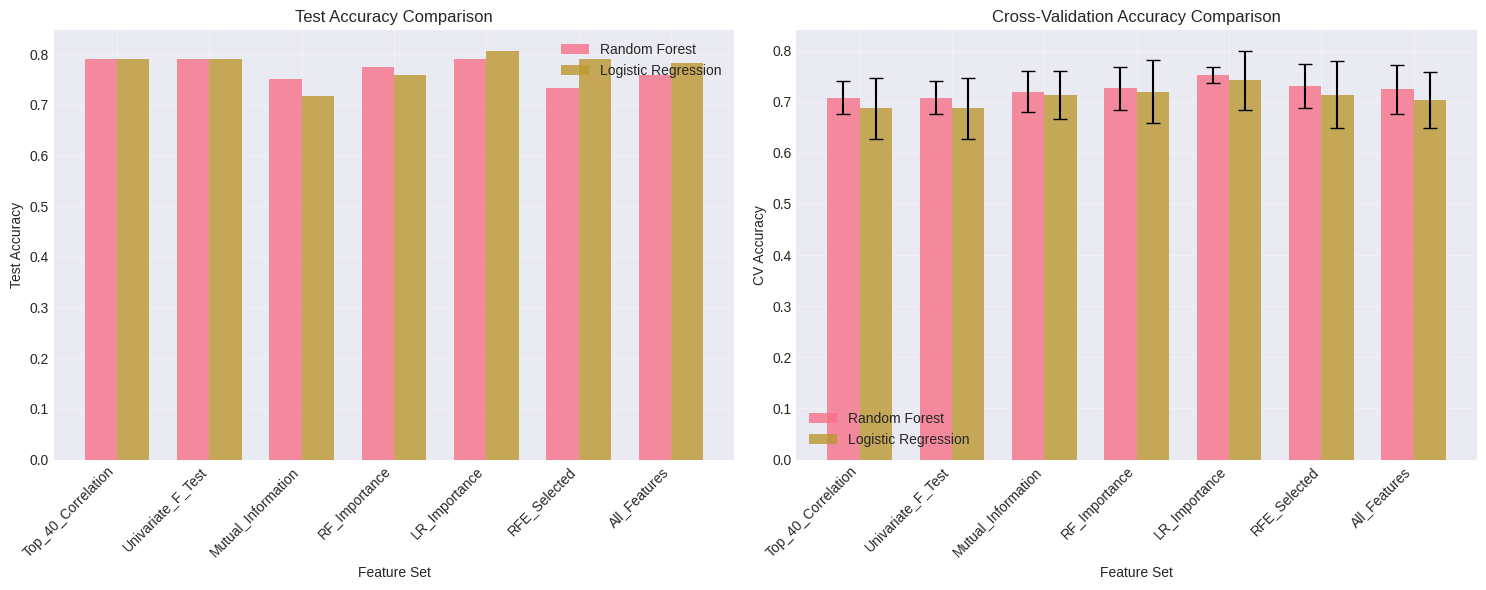


BEST PERFORMING CONFIGURATIONS

Best Random Forest:
  Feature Set: Top_40_Correlation
  Test Accuracy: 0.7903
  CV Accuracy: 0.7077 (+/- 0.0320)

Best Logistic Regression:
  Feature Set: LR_Importance
  Test Accuracy: 0.8065
  CV Accuracy: 0.7418 (+/- 0.0578)

ANALYSIS COMPLETE!


In [12]:
# ============================================
# 7. FINAL COMPARISON SUMMARY
# ============================================
results_df = pd.DataFrame(results_summary)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Test Accuracy Comparison
x_pos = np.arange(len(results_df))
width = 0.35

axes[0].bar(x_pos - width/2, results_df['RF_Test_Accuracy'], width,
            label='Random Forest', alpha=0.8)
axes[0].bar(x_pos + width/2, results_df['LR_Test_Accuracy'], width,
            label='Logistic Regression', alpha=0.8)
axes[0].set_xlabel('Feature Set')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(results_df['Feature_Set'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CV Accuracy Comparison
axes[1].bar(x_pos - width/2, results_df['RF_CV_Mean'], width,
            yerr=results_df['RF_CV_Std'], label='Random Forest',
            alpha=0.8, capsize=5)
axes[1].bar(x_pos + width/2, results_df['LR_CV_Mean'], width,
            yerr=results_df['LR_CV_Std'], label='Logistic Regression',
            alpha=0.8, capsize=5)
axes[1].set_xlabel('Feature Set')
axes[1].set_ylabel('CV Accuracy')
axes[1].set_title('Cross-Validation Accuracy Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(results_df['Feature_Set'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best performing configurations
best_rf_idx = results_df['RF_Test_Accuracy'].idxmax()
best_lr_idx = results_df['LR_Test_Accuracy'].idxmax()

print("\n" + "="*60)
print("BEST PERFORMING CONFIGURATIONS")
print("="*60)
print(f"\nBest Random Forest:")
print(f"  Feature Set: {results_df.loc[best_rf_idx, 'Feature_Set']}")
print(f"  Test Accuracy: {results_df.loc[best_rf_idx, 'RF_Test_Accuracy']:.4f}")
print(f"  CV Accuracy: {results_df.loc[best_rf_idx, 'RF_CV_Mean']:.4f} "
      f"(+/- {results_df.loc[best_rf_idx, 'RF_CV_Std']:.4f})")

print(f"\nBest Logistic Regression:")
print(f"  Feature Set: {results_df.loc[best_lr_idx, 'Feature_Set']}")
print(f"  Test Accuracy: {results_df.loc[best_lr_idx, 'LR_Test_Accuracy']:.4f}")
print(f"  CV Accuracy: {results_df.loc[best_lr_idx, 'LR_CV_Mean']:.4f} "
      f"(+/- {results_df.loc[best_lr_idx, 'LR_CV_Std']:.4f})")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)